# Electrical Time Series Data Classification with ResnetID

## Prepare Notebook

In [16]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Imports

In [17]:
import numpy as np
import os
import src.data.io as data_io
from src.data.split import stratified_split
from src.utils.visualization import plot_training_history
from src.deployment.export import (
    tflite_to_c_header, 
    export_tflite_int8
)
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)
from src.deployment.inference import (
    load_tflite_model, 
    run_tflite_inference
)
from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint
)
from tensorflow.keras.layers import (
    Input, 
    Conv1D, 
    BatchNormalization, 
    Add, 
    ReLU, 
    GlobalAveragePooling1D, 
    Dense
)
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    classification_report
)


## Data Preparation

### Data Loading

In [18]:
ed_data, ed_labels = data_io.load_data_sliding()

X_train, X_test, y_train, y_test = stratified_split(ed_data, ed_labels)
X_train, X_test = clean_train_test(X_train, X_test)
X_train, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_test)

X_train_final, X_val, y_train_final, y_val = stratified_split(X_train, y_train)
y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(
    y_train_final, y_val, y_test
)

print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Stratified split successful
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
Stratified split successful
One-hot encoding complete. Classes: 9

Final shapes:
Train (27105, 30, 5)
Val (6777, 30, 5)
Test (8471, 30, 5)
Classes: 9


### Dataset Size

In [19]:
train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 31.02 MB


## ResnetID Model

### Building

In [20]:
def resnet_block(x, filters):
    skip = x

    x = Conv1D(filters, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = Conv1D(filters, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    if skip.shape[-1] != filters:
        skip = Conv1D(filters, kernel_size=1, padding='same', activation=None)(skip)

    x = Add()([x, skip])
    x = ReLU()(x)

    return x


def build_resnet_id(input_shape=(30, 5), num_classes=9):
    inputs = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x, 32)
    x = resnet_block(x, 64)
    x = resnet_block(x, 128)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    return model

resnet_id_model = build_resnet_id()

resnet_id_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

resnet_id_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 30, 5)]              0         []                            
                                                                                                  
 conv1d_10 (Conv1D)          (None, 30, 64)               1024      ['input_2[0][0]']             
                                                                                                  
 batch_normalization_7 (Bat  (None, 30, 64)               256       ['conv1d_10[0][0]']           
 chNormalization)                                                                                 
                                                                                                  
 conv1d_11 (Conv1D)          (None, 30, 32)               6176      ['batch_normalization_7[

### Training

In [21]:
def train_resnet_id(model, X_train, y_train, X_val, y_val,
                    epochs=30, batch_size=32, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("best_resnet_id_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_resnet_id(resnet_id_model,
                          X_train_final, y_train_final,
                          X_val, y_val,
                          epochs=50,
                          batch_size=32,
                          save_best_model=True)

Epoch 1/50
848/848 [==============================] - 36s 35ms/step - loss: 0.4033 - accuracy: 0.8609 - val_loss: 1.1153 - val_accuracy: 0.7584 - lr: 0.0010
Epoch 2/50
  1/848 [..............................] - ETA: 20s - loss: 0.2546 - accuracy: 0.8750

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


848/848 [==============================] - 31s 37ms/step - loss: 0.2505 - accuracy: 0.9080 - val_loss: 0.3203 - val_accuracy: 0.8539 - lr: 0.0010
Epoch 3/50
848/848 [==============================] - 31s 37ms/step - loss: 0.2032 - accuracy: 0.9244 - val_loss: 0.2918 - val_accuracy: 0.8768 - lr: 0.0010
Epoch 4/50
848/848 [==============================] - 40s 47ms/step - loss: 0.1636 - accuracy: 0.9369 - val_loss: 0.4526 - val_accuracy: 0.8246 - lr: 0.0010
Epoch 5/50
848/848 [==============================] - 40s 48ms/step - loss: 0.1453 - accuracy: 0.9435 - val_loss: 0.5377 - val_accuracy: 0.8741 - lr: 0.0010
Epoch 6/50
848/848 [==============================] - 38s 45ms/step - loss: 0.1347 - accuracy: 0.9484 - val_loss: 0.1097 - val_accuracy: 0.9444 - lr: 0.0010
Epoch 7/50
848/848 [==============================] - 36s 43ms/step - loss: 0.1161 - accuracy: 0.9543 - val_loss: 0.3160 - val_accuracy: 0.8651 - lr: 0.0010
Epoch 8/50
848/848 [==============================] - 24s 29ms/step -

## Evaluation

### Training Performance

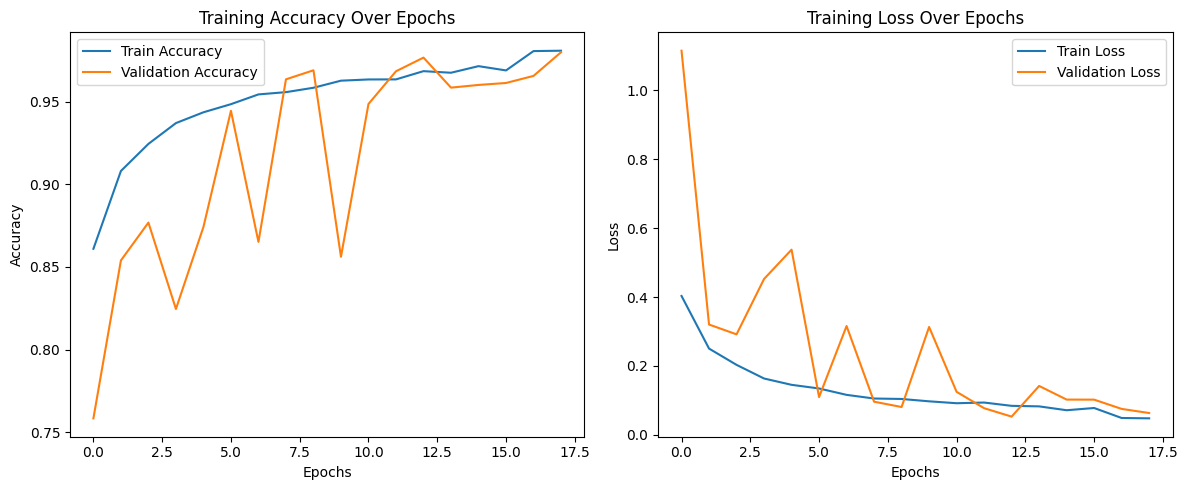

In [22]:
plot_training_history(history)

### Classification Metrics

265/265 [==============================] - 2s 5ms/step

Test Accuracy: 0.9811

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    1.0000    1.0000       188
           2     0.9803    0.8839    0.9296       508
           3     0.8499    0.8954    0.8721       373
           4     0.9852    0.9973    0.9912      2603
           5     0.9964    0.9933    0.9948      1938
           6     0.9884    1.0000    0.9942       511
           7     1.0000    0.6327    0.7750        98
           8     0.9195    0.9870    0.9521       463

    accuracy                         0.9811      8471
   macro avg     0.9689    0.9322    0.9454      8471
weighted avg     0.9817    0.9811    0.9807      8471



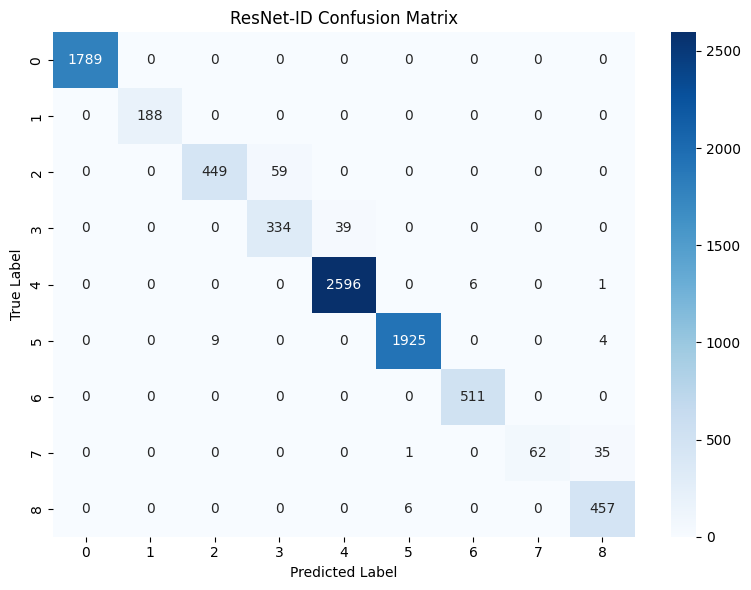

In [23]:
accuracy, report, y_pred = evaluate_classification(
    resnet_id_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="ResNet-ID Confusion Matrix"
)

### Model Saving and Size Check

In [24]:
resnet_id_model.save("../../models/resnet_id_model.h5")

model_size = os.path.getsize("../../models/resnet_id_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 1.72 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [25]:
TFLITE_MODEL_PATH = "../../models/resnet_id_model_quantized.tflite"

export_tflite_int8(
    model=resnet_id_model,
    X_calibration=X_train,
    save_path=TFLITE_MODEL_PATH,
    n_samples=200
)

INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpr2uveb58/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpr2uveb58/assets
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 00:12:48.170138: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 00:12:48.170166: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 00:12:48.170411: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpr2uveb58
2026-03-03 00:12:48.173907: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 00:12:48.173915: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/fold

Quantized model saved: ../../models/resnet_id_model_quantized.tflite (174.10 KB)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


b'\x1c\x00\x00\x00TFL3\x14\x00 \x00\x1c\x00\x18\x00\x14\x00\x10\x00\x0c\x00\x00\x00\x08\x00\x04\x00\x14\x00\x00\x00\x1c\x00\x00\x00\x80\x00\x00\x00\xd8\x00\x00\x00\x98\x1b\x02\x00\xa8\x1b\x02\x00t\xb7\x02\x00\x03\x00\x00\x00\x01\x00\x00\x00\x04\x00\x00\x00\x8e\xdb\xfd\xff\x0c\x00\x00\x00\x1c\x00\x00\x008\x00\x00\x00\x0f\x00\x00\x00serving_default\x00\x01\x00\x00\x00\x04\x00\x00\x00\x9c\xff\xff\xffX\x00\x00\x00\x04\x00\x00\x00\x07\x00\x00\x00dense_3\x00\x01\x00\x00\x00\x04\x00\x00\x00\xaa\xe3\xfd\xff\x04\x00\x00\x00\x07\x00\x00\x00input_2\x00\x02\x00\x00\x004\x00\x00\x00\x04\x00\x00\x00\xdc\xff\xff\xff[\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00CONVERSION_METADATA\x00\x08\x00\x0c\x00\x08\x00\x04\x00\x08\x00\x00\x00Z\x00\x00\x00\x04\x00\x00\x00\x13\x00\x00\x00min_runtime_version\x00\\\x00\x00\x00\xbc\x1a\x02\x00\xb4\x1a\x02\x00\xa0\x1a\x02\x00\x84\x1a\x02\x00h\x1a\x02\x00L\x1a\x02\x008\x1a\x02\x00\x04\x1a\x02\x00t\x15\x02\x00d\x13\x02\x00T\xd3\x01\x00D\xd1\x01\x004\xb1\x01\x00\xa4\xb0\x

### Evaluation

In [26]:
interpreter = load_tflite_model(TFLITE_MODEL_PATH)

y_pred = run_tflite_inference(interpreter, X_test)
y_true = np.argmax(y_test, axis=1)

print("TFLite model prediction completed.")

TFLite model prediction completed.


### Test Classification Report

In [27]:
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9543
Precision: 0.9579
Recall: 0.9543
F1-score: 0.9551

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     0.8951    0.6809    0.7734       188
           2     0.9614    0.8819    0.9199       508
           3     0.8499    0.8954    0.8721       373
           4     0.9715    0.9704    0.9710      2603
           5     0.9840    0.9515    0.9675      1938
           6     0.9215    0.9883    0.9537       511
           7     0.4932    0.7449    0.5935        98
           8     0.8569    0.9438    0.8983       463

    accuracy                         0.9543      8471
   macro avg     0.8815    0.8952    0.8833      8471
weighted avg     0.9579    0.9543    0.9551      8471



### Confusion Matrix

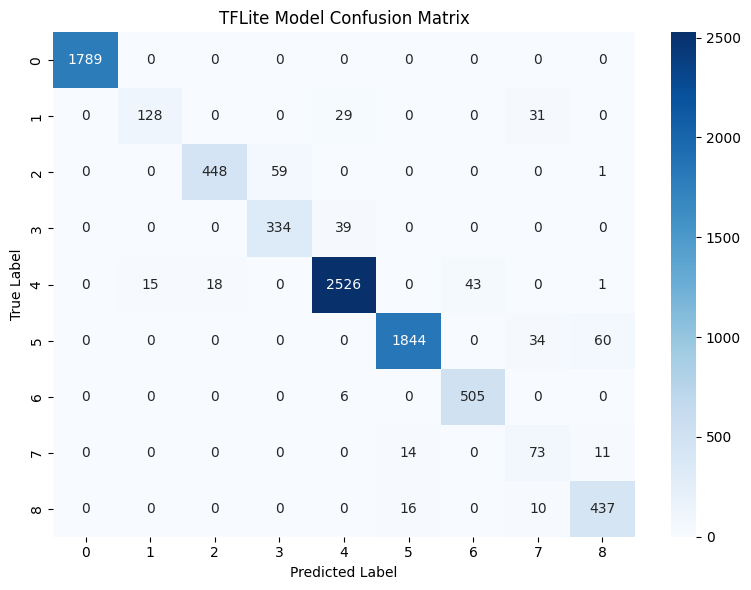

In [28]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

### Model Size

In [29]:
tflite_model_path = "../../models/resnet_id_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 174.10 KB


### ESP32 Compatible Header File Creation

In [30]:
tflite_to_c_header(
    "../../models/resnet_id_model_quantized.tflite",
    var_name="resnet_id_model"
)

C header created: ../../models/resnet_id_model_quantized.h
Size: 174.10 KB


PosixPath('../../models/resnet_id_model_quantized.h')